**Topic: Cryptocurrency Market Index Visualization (Based on CRIX Model) for Money Flow Trend Analysis**

To begin the project, we need to install and use the yfinance library. This is an extremely popular open-source library that acts as a "bridge" allowing direct access to Yahoo Finance's massive database.

Through this tool, we will make automated requests to download the historical data of the top 10 cryptocurrencies. Key metrics extracted include:

Close price: To determine the coin's value at the end of the day.

Volume: To measure the strength of money flow into each project.

**LIST OF 10 COINS:**

BTC (Bitcoin): Acts as a store of value.

ETH (Ethereum): The leading platform for smart contracts and decentralized applications (dApps).

BNB (Binance Coin): The ecosystem coin of the world's largest exchange-based token.

SOL (Solana): Represents high-performance blockchains with extremely fast transaction speeds and low costs.

XRP (Ripple): A specialized coin for cross-border payments.

ADA (Cardano): A blockchain platform focused on science and sustainability.

AVAX (Avalanche): A strong competitor in decentralized finance (DeFi) with high scalability.

DOGE (Dogecoin): Represents the "Meme coin" group but has a massive market cap and community.

DOT (Polkadot): A solution for interoperability between different blockchains.

TRX (TRON): A strong platform in entertainment and digital content sharing.

In [359]:
%pip install -q yfinance nbformat
%pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**FETCH DATA OVER 4 YEARS**

In [360]:
import yfinance as yf
import pandas as pd

# 1. Coin list
coins = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD',
         'ADA-USD', 'AVAX-USD', 'DOGE-USD', 'DOT-USD', 'TRX-USD']

final_df = pd.DataFrame()

print("🚀 Fetching data...")

for symbol in coins:
    try:
        print(f"Fetching: {symbol}...", end="")

        data = yf.download(
            symbol,
            start="2022-01-05",
            end="2026-01-06",
            progress=False
        )

        # ⚠️ Check data
        if data is None or data.empty:
            print(" -> ❌ No data!")
            continue

        name = symbol.split('-')[0].lower()

        # 2. Only get Close + Volume
        df_coin = data[['Close', 'Volume']].copy()

        # ⚠️ Standardize names
        df_coin.rename(columns={
            'Close': f'{name}_price',
            'Volume': f'{name}_volume'
        }, inplace=True)

        # ⚠️ use join (correct)
        if final_df.empty:
            final_df = df_coin
        else:
            final_df = final_df.join(df_coin, how='outer')

        print(" -> ✅ Done!")

    except Exception as e:
        print(f" -> ❌ Error: {e}")

# 3. Process index
final_df.index = pd.to_datetime(final_df.index)
final_df = final_df.sort_index()

# 4. Fill missing
final_df = final_df.ffill()

# 5. Reset index
final_df.reset_index(inplace=True)
final_df.rename(columns={'index': 'Date'}, inplace=True)

print("\n🔥 RESULT:")
display(final_df.head())

# 6. Save raw file
final_df.to_csv("crypto_2026.csv", index=False)

print("\n✅ Clean file saved: crypto_2026.csv")

🚀 Fetching data...
Fetching: BTC-USD... -> ✅ Done!
Fetching: ETH-USD... -> ✅ Done!
Fetching: BNB-USD... -> ✅ Done!
Fetching: SOL-USD... -> ✅ Done!
Fetching: XRP-USD... -> ✅ Done!
Fetching: ADA-USD... -> ✅ Done!
Fetching: AVAX-USD... -> ✅ Done!
Fetching: DOGE-USD... -> ✅ Done!
Fetching: DOT-USD... -> ✅ Done!
Fetching: TRX-USD... -> ✅ Done!

🔥 RESULT:


Price,Date,btc_price,btc_volume,eth_price,eth_volume,bnb_price,bnb_volume,sol_price,sol_volume,xrp_price,...,ada_price,ada_volume,avax_price,avax_volume,doge_price,doge_volume,dot_price,dot_volume,trx_price,trx_volume
Ticker,,BTC-USD,BTC-USD,ETH-USD,ETH-USD,BNB-USD,BNB-USD,SOL-USD,SOL-USD,XRP-USD,...,ADA-USD,ADA-USD,AVAX-USD,AVAX-USD,DOGE-USD,DOGE-USD,DOT-USD,DOT-USD,TRX-USD,TRX-USD
0,2022-01-05,43569.003906,36851084859,3550.386963,18061338502,475.056946,2870757788,155.099731,2123759721,0.774358,...,1.236002,1416139355,97.852577,1168896098,0.159420,994086848,26.796141,1721841153,0.071382,1548312023
1,2022-01-06,43160.929688,30208048289,3418.408203,24293791313,473.275604,4400228627,150.431351,2097172620,0.781346,...,1.279782,1559075484,95.198540,909261500,0.160213,715345645,26.760822,1444988536,0.071112,1852557542
2,2022-01-07,41557.902344,84196607520,3193.210449,24494179209,447.788483,4613172287,136.402817,2926269672,0.763074,...,1.211547,1751707653,86.767715,1163318424,0.155023,969384523,24.925240,2764194355,0.068126,1606695992
3,2022-01-08,41733.941406,28066355845,3091.972656,16037732700,430.246155,4068139021,142.513458,2730000333,0.747688,...,1.187512,1499054949,84.056839,1021954391,0.151954,584437036,24.029129,1546276235,0.065722,1054607408
4,2022-01-09,41911.601562,21294384372,3157.751465,12334683863,438.803070,3347862691,140.839005,1599123912,0.754505,...,1.173860,1088569809,89.206558,900030318,0.151065,408786249,24.627319,1328484247,0.066267,888640481



✅ Clean file saved: crypto_2026.csv


**DATA PREPARATION**

In [361]:
import pandas as pd

# 1. Load raw file
df = pd.read_csv('crypto_2026.csv')

# 2. Identify columns
vol_cols = [col for col in df.columns if 'volume' in col]
price_cols = [col for col in df.columns if 'price' in col]

# 3. Convert to numeric
for col in vol_cols + price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Clean up empty rows and reset index
df.dropna(how='all', inplace=True) # Remove completely empty rows
df.dropna(inplace=True)           # Remove rows with any NaN
df.reset_index(drop=True, inplace=True)

# 5. Process volume (divide by 1M)
df[vol_cols] = df[vol_cols] / 1_000_000

# (Optional) round volume
df[vol_cols] = df[vol_cols].round(2)

# 6. Rename volume columns
new_names = {col: col.replace('volume', 'vol_M') for col in vol_cols}
df.rename(columns=new_names, inplace=True)

# 7. Save clean file
df.to_csv('crypto_2026_clean.csv', index=False)

print("✅ Clean file saved!")
display(df.head())

✅ Clean file saved!


,Date,btc_price,btc_vol_M,eth_price,eth_vol_M,bnb_price,bnb_vol_M,sol_price,sol_vol_M,xrp_price,...,ada_price,ada_vol_M,avax_price,avax_vol_M,doge_price,doge_vol_M,dot_price,dot_vol_M,trx_price,trx_vol_M
0,2022-01-05,43569.003906,36851.08,3550.386963,18061.34,475.056946,2870.76,155.099731,2123.76,0.774358,...,1.236002,1416.14,97.852577,1168.90,0.159420,994.09,26.796141,1721.84,0.071382,1548.31
1,2022-01-06,43160.929688,30208.05,3418.408203,24293.79,473.275604,4400.23,150.431351,2097.17,0.781346,...,1.279782,1559.08,95.198540,909.26,0.160213,715.35,26.760822,1444.99,0.071112,1852.56
2,2022-01-07,41557.902344,84196.61,3193.210449,24494.18,447.788483,4613.17,136.402817,2926.27,0.763074,...,1.211547,1751.71,86.767715,1163.32,0.155023,969.38,24.925240,2764.19,0.068126,1606.70
3,2022-01-08,41733.941406,28066.36,3091.972656,16037.73,430.246155,4068.14,142.513458,2730.00,0.747688,...,1.187512,1499.05,84.056839,1021.95,0.151954,584.44,24.029129,1546.28,0.065722,1054.61
4,2022-01-09,41911.601562,21294.38,3157.751465,12334.68,438.803070,3347.86,140.839005,1599.12,0.754505,...,1.173860,1088.57,89.206558,900.03,0.151065,408.79,24.627319,1328.48,0.066267,888.64


**LOAD DATA AND PREPARATION**

In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('crypto_2026_clean.csv')

# ⚠️ FIX: ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Identify columns
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

print("✅ Data loaded and columns identified successfully!")

✅ Data loaded and columns identified successfully!


**CALCULATE TOTAL TRADING VOLUME**

In [363]:
# Calculate total trading volume of all 10 coins per day
df['Total_Volume'] = df[vol_cols].sum(axis=1)

# Display results
df[['Total_Volume']].head()

,Total_Volume
Date,
2022-01-05,69008.95
2022-01-06,69645.50
2022-01-07,126815.15
2022-01-08,58400.65
2022-01-09,44373.05


### Calculate Total Volume

The total trading volume each day is calculated by summing the trading volumes of all cryptocurrencies in the portfolio.

Specifically, `df[vol_cols].sum(axis=1)` performs row-wise addition (i.e., day by day), thereby creating a new column `Total_Volume` representing the total transaction money flow of the entire market on that day.

This value reflects the activity level and liquidity of the market over time.

**CALCULATE SIMPLE RETURNS**

In [364]:
import numpy as np

# Ensure datetime index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
elif not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# Price columns
price_cols = [c for c in df.columns if 'price' in c]

# PERCENTAGE RETURNS
returns = df[price_cols].pct_change().fillna(0)

# Drop first row
# returns = returns.dropna()  # fillna(0) already handled it

print("✅ Returns summary:")
print(returns.describe())

display(returns.head())

✅ Returns summary:
         btc_price    eth_price    bnb_price    sol_price    xrp_price  \
count  1462.000000  1462.000000  1462.000000  1462.000000  1462.000000   
mean      0.000887     0.000600     0.000903     0.001228     0.001715   
std       0.026922     0.036539     0.030201     0.050925     0.045467   
min      -0.159747    -0.174564    -0.185654    -0.422809    -0.195181   
25%      -0.011312    -0.017383    -0.013148    -0.028034    -0.017916   
50%      -0.000008     0.000187     0.001079    -0.000949     0.000023   
75%       0.013126     0.017382     0.014830     0.027546     0.017138   
max       0.145412     0.217988     0.172340     0.325944     0.730750   

         ada_price   avax_price   doge_price    dot_price    trx_price  
count  1462.000000  1462.000000  1462.000000  1462.000000  1462.000000  
mean      0.000320    -0.000053     0.001138    -0.000782     0.001512  
std       0.047123     0.049932     0.048893     0.042890     0.036153  
min      -0.242796    

,btc_price,eth_price,bnb_price,sol_price,xrp_price,ada_price,avax_price,doge_price,dot_price,trx_price
Date,,,,,,,,,,
2022-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-06,-0.009366,-0.037173,-0.003750,-0.030099,0.009024,0.035421,-0.027123,0.004974,-0.001318,-0.003782
2022-01-07,-0.037141,-0.065878,-0.053853,-0.093255,-0.023385,-0.053318,-0.088560,-0.032394,-0.068592,-0.041990
2022-01-08,0.004236,-0.031704,-0.039175,0.044798,-0.020163,-0.019838,-0.031243,-0.019797,-0.035952,-0.035288
2022-01-09,0.004257,0.021274,0.019888,-0.011749,0.009117,-0.011496,0.061265,-0.005850,0.024894,0.008292


# Analysis: Simple Returns

In financial data analysis and risk measurement models like CRIX, measuring daily price volatility is crucial. **Simple Returns** is one of the most common and easily understood metrics for evaluating asset performance.

### 1. Mathematical Formula
Percentage return is calculated by taking the change in price between today and yesterday divided by yesterday's price:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

*(Where: $P_t$ is the current price, $P_{t-1}$ is the previous day's price)*

### 2. Code Implementation (Python/Pandas)
In Python, we can directly use the built-in `.pct_change()` function from the `pandas` library. This function automatically calculates the percentage change relative to the preceding row:

`returns = df[price_cols].pct_change().fillna(0)`

*(Note: We use `.fillna(0)` to set the return of the first day in the series to 0 instead of causing a NaN error).*

### 3. Why does this model use Simple Returns?
* **Intuitive and Easy to Understand:** Simple Returns accurately reflect the actual profitability an investor receives. For example: If you buy an asset at $100 and sell it at $105, your percentage return is exactly 5%.
* **Portfolio Additivity:** Unlike Log Returns, Simple Returns allow easy calculation of a portfolio's return by taking the weighted sum of the constituent assets' returns. This property is particularly suited for constructing volume-weighted indices like CRIX.

### 4. Example in the dataset (Bitcoin on Jan 06 - Jan 07, 2022)
Extracting the actual price data of Bitcoin for the 2 days Jan 06, 2022 and Jan 07, 2022:
* Closing price on Jan 06, 2022: **$43,160.93**
* Closing price on Jan 07, 2022: **$41,557.90**

**Applying the Simple Return formula for Jan 07, 2022:**
$$r = \frac{41557.90 - 43160.93}{43160.93} = \frac{-1603.03}{43160.93} \approx \textbf{-0.037141}$$

> **Conclusion:** The number `-0.037141` is the return value recorded in the `returns` dataset for Jan 07, 2022. It represents an approximate 3.71% decline in Bitcoin on that day compared to the previous day.

**CALCULATE WEIGHTED RETURNS (BY VOLUME)**

In [365]:
# Calculate total volume per day
total_vol = df[vol_cols].sum(axis=1)

# Calculate weight matrix
weights = df[vol_cols].div(total_vol, axis=0)

# Rename weight columns to match returns
weights.columns = [col.replace('vol_M', 'price') for col in weights.columns]

# Calculate weighted returns
weighted_returns = (weights * returns).sum(axis=1)

# View results
weighted_returns.head()

Date
2022-01-05    0.000000
2022-01-06   -0.017530
2022-01-07   -0.045747
2022-01-08   -0.010767
2022-01-09    0.011095
dtype: float64

### Calculate Volume-Weighted Returns

In this step, the return rate of each coin is combined into a single value for the entire market, based on its trading volume weight.

Specifically, at each point in time, the weight of an asset is calculated by:

$$
w_{i,t} = \frac{Volume_{i,t}}{Total\ Volume_t}
$$

Then, the market's weighted return is calculated by:

$$
r_t = \sum_{i=1}^{n} w_{i,t} \cdot r_{i,t}
$$

---

### Calculation Example (Jan 07, 2022)

Based on the dataset:

- **Total volume on Jan 07, 2022**:
$$
Total\ Volume = 126815.15
$$

---

####  Bitcoin (BTC)

- Volume = 84196.61
- Simple Returns = -0.037141  

Weight:

$$
w_{BTC} = \frac{84196.61}{126815.15} \approx 0.664
$$

Contribution to the market:

$$
0.664 \times -0.037141 \approx -0.024662
$$

---

####  Ethereum (ETH)

- Volume = 24494.18  
- Simple Returns = -0.065878	  

Weight:

$$
w_{ETH} = \frac{24494.18}{126815.15} \approx 0.193
$$

Contribution:

$$
0.193 \times -0.065878 \approx -0.012714
$$

---

####  Summary

The remaining coins are calculated similarly and added up:

$$
r_t = \sum w_i \cdot r_i
$$

Final result:

$$
r_t \approx -0.045747
$$

---

### Result

| Date       | Weighted Return |
|------------|-----------------|
| 2022-01-07 | -0.045747        |

$$
r_t = -0.045747 = -4.57\%
$$

 This shows: **the entire crypto market fell by approximately 4.57% on Jan 07, 2022**, after considering the impact of each coin based on its trading volume.

---

### Conclusion

This method reflects the actual money flow, where assets with large trading volumes (like BTC, ETH) will have a stronger influence on the overall index. Therefore, the CRIX index constructed from weighted returns will more accurately reflect the trend of the entire market.

**CALCULATE CRIX INDEX AND DISPLAY CHART**

✅ CRIX INDEX CALCULATION RESULTS (FIRST 5 DAYS & LAST 5 DAYS):


,Date,CRIX
0,2022-01-05,1000.000000
1,2022-01-06,982.470015
2,2022-01-07,937.524751
3,2022-01-08,927.430068
4,2022-01-09,937.719697


...


,Date,CRIX
1457,2026-01-01,6849.904665
1458,2026-01-02,7059.120408
1459,2026-01-03,7094.801172
1460,2026-01-04,7174.483619
1461,2026-01-05,7411.266412


--------------------------------------------------


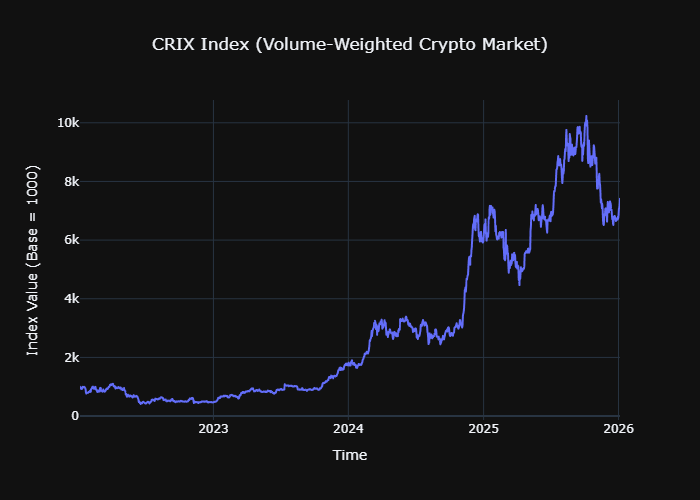

In [366]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"
from IPython.display import display

# ===== 1. Load data =====
df = pd.read_csv('crypto_2026_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# ===== 2. Automatically identify columns =====
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

# ===== 3. Total Volume =====
df['Total_Volume'] = df[vol_cols].sum(axis=1)

# ===== 4. LOG RETURN =====
returns = df[price_cols].pct_change().fillna(0)

# ===== 5. WEIGHTED RETURNS =====
weighted_returns = pd.Series(0.0, index=returns.index)

for v_col in vol_cols:
    p_col = v_col.replace('vol_M', 'price').replace('volume', 'price')

    weight = (
        df[v_col] /
        df['Total_Volume']
    )

    weighted_returns += weight * returns[p_col]

# ===== 6. CRIX =====
crix = [1000.0]

for r in weighted_returns.iloc[1:]:
    crix.append(crix[-1] * (1 + r))

df['CRIX'] = crix

# ===== 7. RESET INDEX to plot =====
df_plot = df[['CRIX']].dropna().reset_index()

# =======================================================
# ===== 7.5. DISPLAY CRIX INDEX RESULTS ====
# =======================================================
print("✅ CRIX INDEX CALCULATION RESULTS (FIRST 5 DAYS & LAST 5 DAYS):")

display(df_plot.head())
print("...")
display(df_plot.tail())
print("-" * 50)

# ===== 8. PLOTLY VISUALIZATION =====
fig = px.line(
    df_plot,
    x='Date',
    y='CRIX',
    title='CRIX Index (Volume-Weighted Crypto Market)',
    labels={'CRIX': 'Index Value (Base = 1000)', 'Date': 'Time'}
)

# Enhance visual appeal
fig.update_layout(
    template='plotly_dark',   # Professional dark background
    title_x=0.5,              # Center title
    hovermode='x unified'     # Hover one point for all
)

fig.show()

### Example: Calculating CRIX for Jan 06, 2022
We will use actual data from the dataset for **Jan 05, 2022** and **Jan 06, 2022**. For simplicity, this example details the calculation for the 2 coins with the largest weights (BTC and ETH), the remaining coins follow the exact same algorithm.

**Actual data on Jan 06, 2022:**
* **Total market money flow (Total Volume of 10 coins):** **69,645.50 M$** (Million USD)
* **Bitcoin (BTC):**
  * Price on Jan 05: $43,569.00
  * Price on Jan 06: $43,160.93
  * Volume on Jan 06: **30,208.05 M$**
* **Ethereum (ETH):**
  * Price on Jan 05: $3,550.39
  * Price on Jan 06: $3,418.41
  * Volume on Jan 06: **24,293.79 M$**
* **Starting CRIX points (Jan 05, 2022):** **1000.00 points**.

---

#### Step 1: Calculate Simple Return ($r$) for each coin
Apply the Percentage Return formula: $r = \frac{P_{t} - P_{t-1}}{P_{t-1}}$
* **BTC Return ($r_{BTC}$):** $\frac{43160.93 - 43569.00}{43569.00} \approx \textbf{-0.009366}$ (Decrease ~0.94%)
* **ETH Return ($r_{ETH}$):** $\frac{3418.41 - 3550.39}{3550.39} \approx \textbf{-0.037173}$ (Decrease ~3.72%)

#### Step 2: Calculate Money Flow Weight ($W$)
Trading Volume determines the "weight" of that coin in the index:
* **BTC Weight ($W_{BTC}$):** $30208.05 / 69645.50 \approx \textbf{0.4337}$ (Accounts for 43.37% of the market)
* **ETH Weight ($W_{ETH}$):** $24293.79 / 69645.50 \approx \textbf{0.3488}$ (Accounts for 34.88% of the market)

#### Step 3: Calculate Overall Market Return ($R_m$)
Multiply the weight by the return of each coin and add them up (the algorithm computes for all 10 coins):
$$
R_m = (W_{BTC} \times r_{BTC}) + (W_{ETH} \times r_{ETH}) + \dots + (W_{TRX} \times r_{TRX})
$$
$$
R_m = (0.4337 \times -0.009366) + (0.3488 \times -0.037173) + \dots (\text{the other 8 coins})
$$
*(The Python algorithm, after scanning all 10 coins, will yield the overall market return on Jan 06 as **$R_m = -0.017530$**)*

#### Step 4: Update CRIX Score
Use the simple return formula to update the CRIX Score:
$$
\text{CRIX}_{06/01} = \text{CRIX}_{05/01} \times (1 + R_m)
$$
$$
\text{CRIX}_{06/01} = 1000 \times (1 - 0.017530)
$$
$$
\text{CRIX}_{06/01} \approx 1000 \times 0.982470 \approx \textbf{982.47}
$$

> **Insight Conclusion:** Based on actual data, on Jan 06, 2022, although BTC only slightly decreased by 0.94%, ETH sharply dropped by 3.72% combined with other Altcoins going down, pulling the overall index lower. Aggregated by volume weight, the entire market caused the CRIX index to fall from **1000** to **982.47 points** (a drop of about 1.75% after just 1 day).

* **Overall Trend:** The market experiences high volatility. The index sees explosive growth throughout the 2023 - 2025 period and peaks in October 2025 before a downward correction towards the end of the year.
* **Bottom Area (June 2022):** The index dropped to a historical low of **411.36 points** on June 18, 2022, reflecting a gloomy period for the market (crypto winter).
* **Highest Peak (Oct 06, 2025):** Reached **10,231.62 points** (more than a 10x increase from the 1000 baseline). This marks the most euphoric phase of the market.
* **Correction Phase (Nov 2025):** A freefall from the peak occurred as the index dropped back to **6,513.64 points** on November 22, 2025.
* **Conclusion:** The chart demonstrates the very rapid cyclicality of the Crypto market: CRIX took nearly 4 years to accumulate and peak but could drop over 36% in less than 2 months.

### Analysis: Money Flow Distribution Between Coins (2022 - 2026)

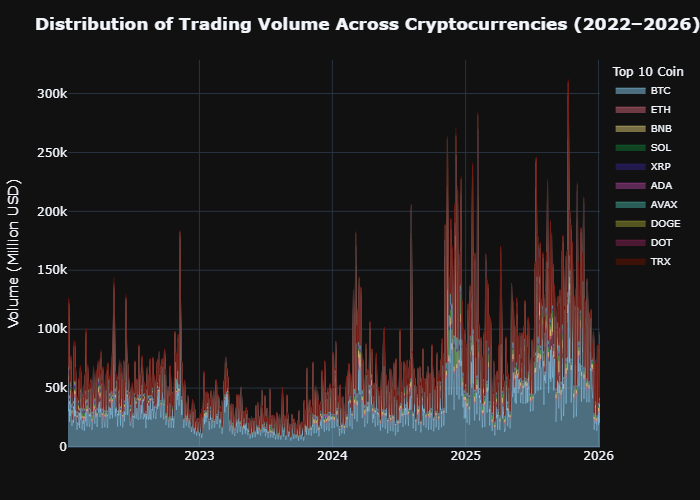

In [367]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"

# 1. Load Clean 4 years Dataset
df = pd.read_csv('crypto_2026_clean.csv')

# Convert Date to Datetime and Set as Index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Extract Volume Columns (vol_M)
vol_cols = [col for col in df.columns if 'vol_M' in col]

# =========================================================
# =========================================================

# Extract and Standardize Volume Data
df_vol_plot = df[vol_cols].copy()
df_vol_plot.columns = [c.split('_')[0].upper() for c in vol_cols]

# Extract and Standardize Volume Data
df_vol_plot = df_vol_plot.sort_index()

# Plot an Area Chart
fig2 = px.area(
    df_vol_plot,
    x=df_vol_plot.index,
    y=df_vol_plot.columns,
    title='<b>Distribution of Trading Volume Across Cryptocurrencies (2022–2026)</b>',
    color_discrete_sequence=px.colors.qualitative.Safe, 
    labels={"value": "Volume (Million USD)", "variable": "Coin"}
)

fig2.update_layout(
    template='plotly_dark',
    xaxis_title='',
    yaxis_title='Volume (Million USD)',
    legend_title='Top 10 Coin',
    hovermode='x unified',
    legend=dict(
        font=dict(size=10),
        itemclick="toggleothers", # Double-click a coin to hide all others.
    ),
    margin=dict(l=40, r=40, t=60, b=40)
)

# Smooth the Lines and Enhance Hover Effects
fig2.update_traces(
    line=dict(width=0.5),
    hovertemplate='%{fullData.name}: %{y:,.2f} M$' # Improve Readability with Thousands Separators and M$ Formatting
)

fig2.show()

* **Dominance of BTC and ETH:** The two largest cryptocurrencies occupy the majority of the chart area, indicating that capital is heavily concentrated in large-cap assets. As of December 31, 2025, BTC recorded a trading volume of over $33.8 billion, while ETH exceeded $16.4 billion.
* **Market Synchronization:** Volume spikes appear consistently across nearly all cryptocurrencies, especially during periods of broad liquidity expansion. This suggests that investor sentiment and capital flows tend to move in line with overall market trends, often led by Bitcoin.
* **Position of Altcoins:** SOL and BNB maintain leading positions among altcoins in terms of liquidity. Other cryptocurrencies such as DOGE, XRP, and ADA account for smaller shares of total volume but still experience occasional short-term surges in trading activity.
* **Year-End Capital Flows:** By late December 2025, although trading volumes had declined from previous peak levels, capital flows remained relatively stable. The majority of liquidity continued to be concentrated in BTC and ETH, reflecting their role as relatively safer assets during periods of market uncertainty.

**Comparison Between CRIX and Bitcoin**

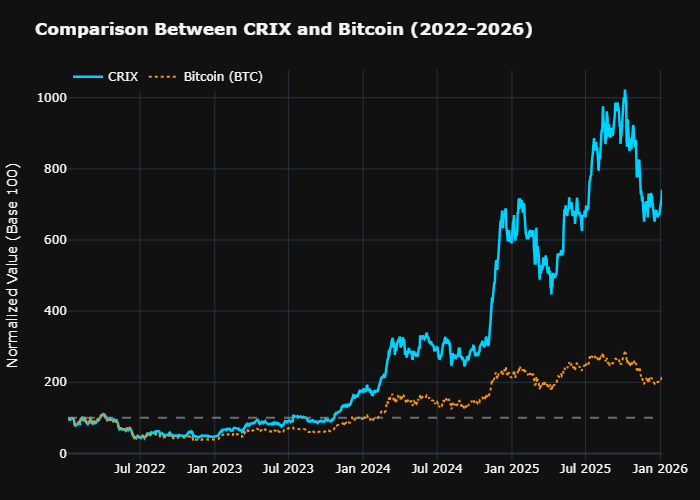

In [368]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

# 1. Verify CRIX Data and Recompute if Missing
price_cols = [c for c in df.columns if 'price' in c.lower()]
vol_cols = [c for c in df.columns if 'vol' in c.lower()]

if 'CRIX' not in df.columns:
    # Calculate simple return
    returns_temp = df[price_cols].pct_change().fillna(0)
    # Calculate total volume
    total_vol_temp = df[vol_cols].sum(axis=1)
    # Calculate weighted returns
    weighted_returns_temp = pd.Series(0.0, index=returns_temp.index)
    for v_col in vol_cols:
        p_col = v_col.replace('vol_M', 'price')
        weight = df[v_col] / total_vol_temp
        weighted_returns_temp += weight * returns_temp[p_col]
    # Create the CRIX Column
    crix_temp = [1000.0]
    for r in weighted_returns_temp.iloc[1:]:
        crix_temp.append(crix_temp[-1] * (1 + r))
    df['CRIX'] = crix_temp

# 2. Normalize to a Base Value of 100 for Comparison
crix_norm = (df['CRIX'] / df['CRIX'].dropna().iloc[0]) * 100
btc_norm = (df['btc_price'] / df['btc_price'].iloc[0]) * 100

# 3. Create the Chart
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=df.index,
    y=crix_norm,
    name='CRIX',
    line=dict(color='#00d2ff', width=2.5),
    hovertemplate='<b>CRIX</b>: %{y:,.2f}<extra></extra>'
))

fig3.add_trace(go.Scatter(
    x=df.index,
    y=btc_norm,
    name='Bitcoin (BTC)',
    line=dict(color='#F7931A', width=2, dash='dot'),
    hovertemplate='<b>BTC</b>: %{y:,.2f}<extra></extra>'
))

# 4. UI Dark Mode
fig3.update_layout(
    title='<b>Comparison Between CRIX and Bitcoin (2022-2026)</b>',
    template='plotly_dark',
    yaxis_title='Normalized Value (Base 100)',
    hovermode='x unified',
    legend=dict(orientation='h', y=1.02, x=0),
    margin=dict(l=50, r=30, t=70, b=40)
)

fig3.add_hline(y=100, line_dash="dash", line_color="#8B949E", opacity=0.7)

fig3.show()


📊 **Original Data Before Normalization**

**January 5, 2022 (Base Date):**
* Bitcoin (BTC) Price: **43,569.00 USD**
* CRIX Index: **1,000.00 points** (default starting value)

**January 6, 2022 (Second Day):**
* Bitcoin (BTC) Price: **43,160.93 USD**
* CRIX Index: **982.47 points** (calculated in previous sections)

The problem here is: how can we plot over 43 thousand dollars and 1 thousand points on the same scale for comparison? Therefore, we need Step 2!

---

🧮 **Perform Step 2: Normalize to base 100**

Formula in code: *Normalized Value = (Current Day Value / First Day Value) \* 100*

**Normalize Bitcoin (BTC) to 100:**
* Jan 05, 2022: $(43,569.00 / 43,569.00) \times 100 = \textbf{100}$
* Jan 06, 2022: $(43,160.93 / 43,569.00) \times 100 \approx \textbf{99.06}$
$\rightarrow$ This means on the second day, BTC reached **99.06 points** (a decrease of 0.94%).

**Normalize CRIX Index to 100:**
* Jan 05, 2022: $(1,000 / 1,000) \times 100 = \textbf{100}$
* Jan 06, 2022: $(982.47 / 1,000) \times 100 \approx \textbf{98.25}$
$\rightarrow$ This means on the second day, CRIX reached **98.25 points** (a decrease of 1.75%).

---

📈 **Growth Rate Comparison Analysis:**

* **Correlation:** CRIX and BTC tend to move tightly in the same direction, however, CRIX has a higher volatility due to the influence of highly volatile Altcoins.
* **Boom Period (July - October 2025):** The CRIX index outperformed Bitcoin. Peaking on Oct 06, 2025, CRIX (normalized) reached over **1,023 points**, while BTC only reached about **286 points**. This shows that Altcoins in the index basket broke out very strongly during this period.
* **Risk Characteristics:** CRIX goes higher, but when the market drops (after October 2025), it also plunges faster than BTC, indicating a higher risk for a diversified portfolio during market reversals.
* **End of Year (Dec 30, 2025):**
  * CRIX (normalized): **678.69** (still maintaining an outstanding growth rate compared to early 2022).
  * BTC (normalized): **202.97** (doubled compared to the starting level).
* **Conclusion:** Throughout the period from 2022 to 2026, investing in the market index (CRIX) yielded better performance than simply holding Bitcoin alone, despite the higher volatility.


**Capital Flow Share by Cryptocurrency**

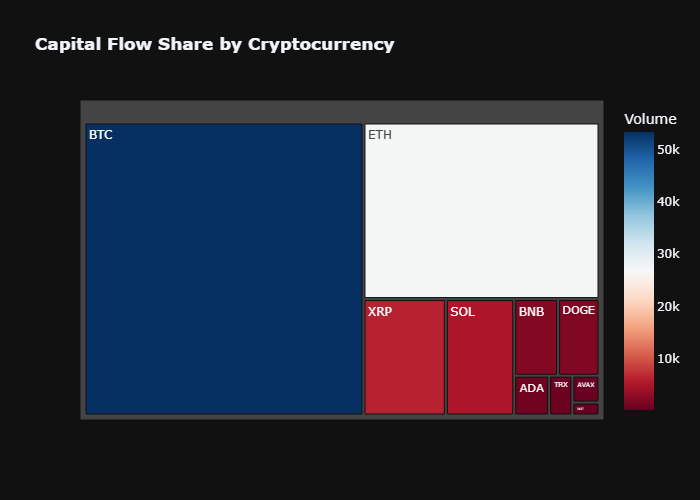

In [369]:
import plotly.express as px
import pandas as pd
import plotly.io as pio
pio.renderers.default = "png"

# Load the clean data (previously processed)
df = pd.read_csv('crypto_2026_clean.csv')
# Extract the Latest Available Data to Analyze the Current Market Structure
latest_data = df_vol_plot.iloc[-1].reset_index()
latest_data.columns = ['Coin', 'Volume']

fig4 = px.treemap(latest_data, path=['Coin'], values='Volume',
                  title='<b>Capital Flow Share by Cryptocurrency </b>',
                  color='Volume', color_continuous_scale='RdBu')

fig4.update_layout(template='plotly_dark')
fig4.show()


* **Absolute dominance of Bitcoin (BTC):** BTC occupies the largest area and has the darkest blue color on the Treemap, corresponding to a massive trading volume (~53.4 billion USD on the last day, Jan 05, 2026). This confirms that BTC is the "center of gravity" navigating the money flow of the entire market.
* **Stratified market structure:**
  * **Leading group:** BTC and ETH overwhelmingly dominate in terms of capitalization and liquidity (large blue/white areas).
  * **Altcoin group:** Coins like SOL, BNB, XRP, DOGE... occupy much smaller areas, showing that money flow begins to strongly diverge when flowing into riskier asset classes.
* **Color & Volume Correlation:** The color scale clearly shows a large liquidity skew. The market is extremely concentrated in the top coins, creating a huge disparity in trading depth among groups.
* **Insight:** This structure shows that investor sentiment still prioritizes the safety and high liquidity of industry-leading assets in a volatile market environment.


**Correlation Matrix**

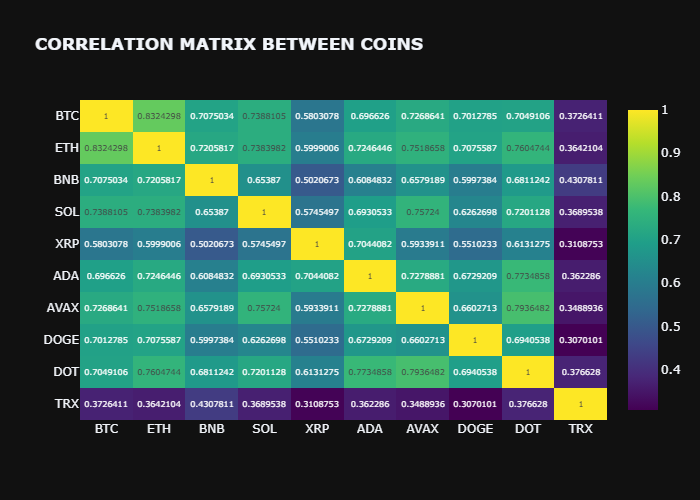

In [370]:
import seaborn as sns
import pandas as pd
import plotly.io as pio
pio.renderers.default = "png"

# Load the clean data (previously processed)
df = pd.read_csv('crypto_2026_clean.csv')
# Calculate the correlation between the returns of 10 coins
corr = returns.corr()
# Simplify Column Names
corr.columns = [c.split('_')[0].upper() for c in corr.columns]
corr.index = corr.columns

fig5 = px.imshow(corr, text_auto=True, aspect="auto",
                title='<b>CORRELATION MATRIX BETWEEN COINS</b>',
                color_continuous_scale='Viridis')

fig5.update_layout(template='plotly_dark')
fig5.show()

* **Strong Positive Correlation:** The majority of major coins have a high correlation coefficient ($r > 0.6$), indicating that they tend to move in the same direction.
  * **BTC & ETH (0.83):** An extremely tight relationship, leading the general trend.
  * **DOT & AVAX (0.79) & DOT & ADA (0.77):** Altcoin pairs with highly synchronized volatility.
* **The Outlier:** TRX is the coin with the lowest correlation coefficient compared to the general market ($r$ only from **0.31 - 0.43**). This indicates that TRX tends to move more independently from the rest of the market.
* **Color Zones:** Brightly colored cells (close to 1) are concentrated heavily in the Top group, proving that when the market experiences strong volatility, these coins will move in the same direction.
* **Insight:** For portfolio diversification and risk minimization, investors should look for pairs with low correlation (like TRX with other coins) instead of putting everything into pairs with excessively high correlation.
